# Codveda Data Analytics Internship - Level 3

Two tasks for this level: **Task 1 (classification)** on a telecom churn dataset and **Task 3 (NLP, sentiment analysis)** on social media posts.

Both datasets were cleaned first with `src/01_clean_data.py`, so this notebook starts from the cleaned files in `data/`. Open it from the main folder of the project.

In [1]:
import re
import warnings
from collections import Counter

import matplotlib.pyplot as plt
import nltk
import numpy as np
import pandas as pd
import seaborn as sns
from nltk.corpus import stopwords
from nltk.sentiment import SentimentIntensityAnalyzer
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (ConfusionMatrixDisplay, RocCurveDisplay, accuracy_score, classification_report,
                             confusion_matrix, f1_score, precision_score, recall_score, roc_auc_score)
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from textblob import TextBlob
from wordcloud import WordCloud

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
SEED = 42

for package in ("punkt", "punkt_tab", "stopwords", "wordnet", "omw-1.4", "vader_lexicon"):
    nltk.download(package, quiet=True)

---
## Task 1 - Predictive modelling (classification)

The question: **which telecom customers are going to leave (churn)?** The data comes in two files, 2,666 customers to train on and 667 to test on, each with 19 variables (plan, minutes and calls per period, customer service calls...) and the `churn` column.

In [2]:
train = pd.read_csv("data/churn_train_clean.csv")
test = pd.read_csv("data/churn_test_clean.csv")

print("train:", train.shape, "| test:", test.shape)
print(f"churn rate: train {train['churn'].mean():.1%}, test {test['churn'].mean():.1%}")
train.head()

train: (2666, 20) | test: (667, 20)
churn rate: train 14.6%, test 14.2%


,state,account_length,area_code,international_plan,voice_mail_plan,number_vmail_messages,total_day_minutes,total_day_calls,total_day_charge,total_eve_minutes,total_eve_calls,total_eve_charge,total_night_minutes,total_night_calls,total_night_charge,total_intl_minutes,total_intl_calls,total_intl_charge,customer_service_calls,churn
0,KS,128,415,No,Yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,0
1,OH,107,415,No,Yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,0
2,NJ,137,415,No,No,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,0
3,OH,84,408,Yes,No,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,0
4,OK,75,415,Yes,No,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,0


Only about 15% of the customers leave. That matters for the rest: a model that always answers "stays" would already be right 86% of the time without finding a single churner. So accuracy alone is not enough here, and I will look at precision, recall and F1 of the churn class.

First, a look at who leaves.

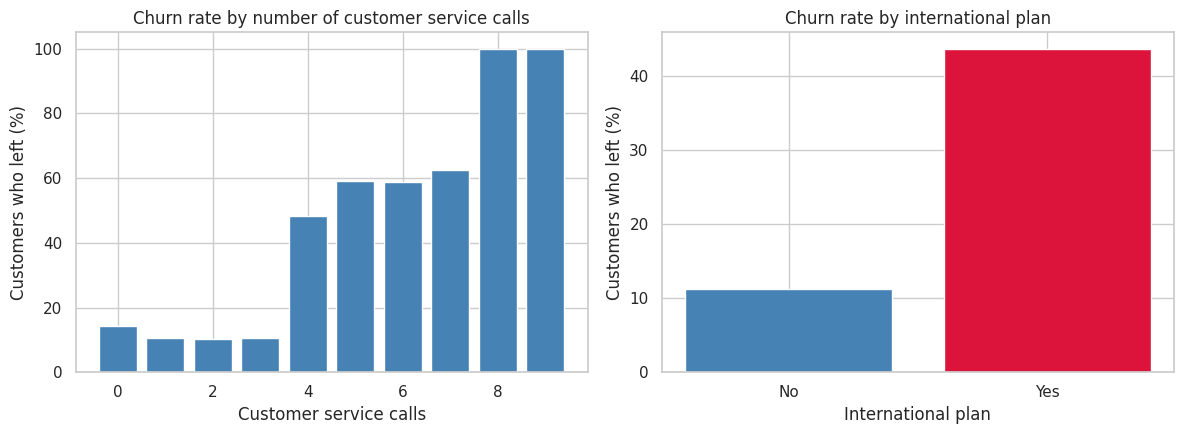

{0: 14.2, 1: 10.5, 2: 10.2, 3: 10.6, 4: 48.1, 5: 59.2, 6: 58.8, 7: 62.5, 8: 100.0, 9: 100.0}
{'No': 11.3, 'Yes': 43.7}


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

by_calls = train.groupby("customer_service_calls")["churn"].mean() * 100
axes[0].bar(by_calls.index, by_calls.values, color="steelblue")
axes[0].set_title("Churn rate by number of customer service calls")
axes[0].set_xlabel("Customer service calls")
axes[0].set_ylabel("Customers who left (%)")

by_plan = train.groupby("international_plan")["churn"].mean() * 100
axes[1].bar(by_plan.index, by_plan.values, color=["steelblue", "crimson"])
axes[1].set_title("Churn rate by international plan")
axes[1].set_xlabel("International plan")
axes[1].set_ylabel("Customers who left (%)")
plt.tight_layout()
plt.show()

print(by_calls.round(1).to_dict())
print(by_plan.round(1).to_dict())

Two things stand out. Up to 3 calls to customer service the churn rate stays around 10-14%, and from the 4th call it jumps to 48% and more. Customers with an international plan leave four times more often (43.7% against 11.3%).

### Preprocessing

- The charge columns are the minutes columns times a fixed price (correlation 1.00), so I drop the charges and keep the minutes.
- Categorical variables (`state`, `area_code`, `international_plan`, `voice_mail_plan`) are one-hot encoded. `area_code` is a number in the file (415, 408, 510) but it is a label, so I treat it as a category.
- Numeric variables are standardized. It does not change anything for the trees but the logistic regression needs it.

In [4]:
DROP = ["total_day_charge", "total_eve_charge", "total_night_charge", "total_intl_charge"]
CATEGORICAL = ["state", "area_code", "international_plan", "voice_mail_plan"]

X_train = train.drop(columns=DROP + ["churn"])
y_train = train["churn"]
X_test = test.drop(columns=DROP + ["churn"])
y_test = test["churn"]
NUMERIC = [c for c in X_train.columns if c not in CATEGORICAL]

X_train["area_code"] = X_train["area_code"].astype(str)
X_test["area_code"] = X_test["area_code"].astype(str)

preprocess = ColumnTransformer([
    ("num", StandardScaler(), NUMERIC),
    ("cat", OneHotEncoder(handle_unknown="ignore"), CATEGORICAL),
])

def make_pipeline(model):
    return Pipeline([("prep", preprocess), ("model", model)])

print(len(NUMERIC), "numeric variables,", len(CATEGORICAL), "categorical variables")

11 numeric variables, 4 categorical variables


### Three models with default settings

`class_weight="balanced"` is used on all of them so the small churn group counts more during training.

In [5]:
models = {
    "Logistic Regression": LogisticRegression(class_weight="balanced", max_iter=2000, random_state=SEED),
    "Decision Tree": DecisionTreeClassifier(class_weight="balanced", random_state=SEED),
    "Random Forest": RandomForestClassifier(class_weight="balanced", n_estimators=200, random_state=SEED, n_jobs=-1),
}

def scores(model, X, y):
    pred = model.predict(X)
    return {
        "accuracy": accuracy_score(y, pred),
        "precision": precision_score(y, pred, zero_division=0),
        "recall": recall_score(y, pred),
        "f1": f1_score(y, pred),
        "roc_auc": roc_auc_score(y, model.predict_proba(X)[:, 1]),
    }

rows = []
for name, model in models.items():
    pipe = make_pipeline(model).fit(X_train, y_train)
    rows.append({"model": name, "version": "default", **scores(pipe, X_test, y_test)})

default_table = pd.DataFrame(rows)
default_table.round(3)

,model,version,accuracy,precision,recall,f1,roc_auc
0,Logistic Regression,default,0.777,0.365,0.768,0.495,0.819
1,Decision Tree,default,0.922,0.736,0.705,0.720,0.832
2,Random Forest,default,0.922,0.978,0.463,0.629,0.913


The logistic regression finds most churners (recall 0.77) but raises many false alarms (precision 0.36). The random forest is the opposite: when it says "churn" it is almost always right (0.98) but it misses more than half of them (recall 0.46). The decision tree sits in between and already has the best F1.

### Grid search

5-fold cross-validation on the training file only, scored with the F1 of the churn class. The test file is not touched until the end.

In [6]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

grids = {
    "Logistic Regression": {"model__C": [0.01, 0.1, 1, 10, 100]},
    "Decision Tree": {
        "model__max_depth": [3, 5, 8, 12, None],
        "model__min_samples_leaf": [1, 5, 10, 20],
        "model__criterion": ["gini", "entropy"],
    },
    "Random Forest": {
        "model__n_estimators": [200, 400],
        "model__max_depth": [8, 12, 20, None],
        "model__min_samples_leaf": [1, 2, 5],
    },
}

tuned, cv_scores, rows = {}, {}, []
for name, model in models.items():
    search = GridSearchCV(make_pipeline(model), grids[name], scoring="f1", cv=cv, n_jobs=-1)
    search.fit(X_train, y_train)
    tuned[name] = search.best_estimator_
    cv_scores[name] = search.best_score_
    rows.append({"model": name, "version": "tuned", **scores(search.best_estimator_, X_test, y_test)})
    best = {k.replace("model__", ""): v for k, v in search.best_params_.items()}
    print(f"{name}: CV F1 = {search.best_score_:.3f}  {best}")

tuned_table = pd.DataFrame(rows)
pd.concat([default_table, tuned_table]).round(3)

Logistic Regression: CV F1 = 0.484  {'C': 0.1}


Decision Tree: CV F1 = 0.752  {'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 1}


Random Forest: CV F1 = 0.785  {'max_depth': 12, 'min_samples_leaf': 2, 'n_estimators': 400}


,model,version,accuracy,precision,recall,f1,roc_auc
0,Logistic Regression,default,0.777,0.365,0.768,0.495,0.819
1,Decision Tree,default,0.922,0.736,0.705,0.720,0.832
2,Random Forest,default,0.922,0.978,0.463,0.629,0.913
0,Logistic Regression,tuned,0.772,0.358,0.758,0.486,0.828
1,Decision Tree,tuned,0.936,0.755,0.811,0.782,0.895
2,Random Forest,tuned,0.934,0.807,0.705,0.753,0.919


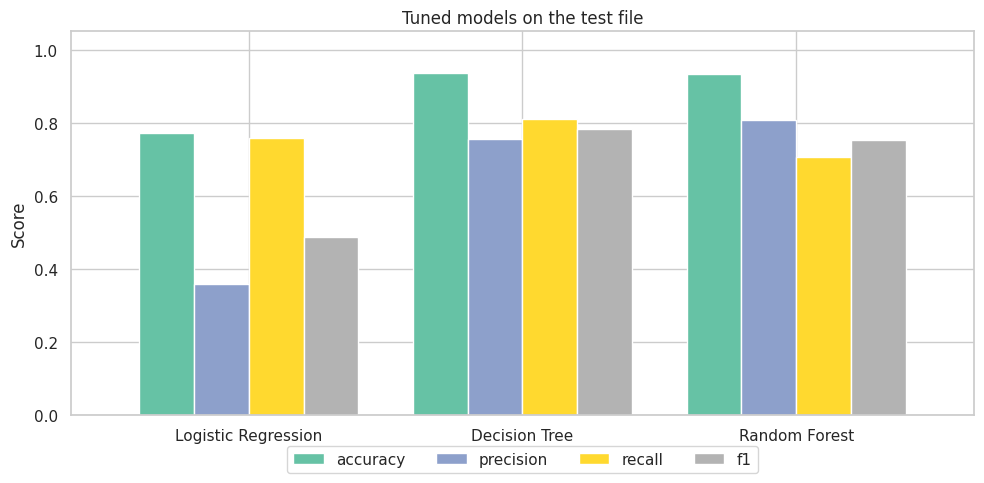

In [7]:
ax = tuned_table.set_index("model")[["accuracy", "precision", "recall", "f1"]].plot(
    kind="bar", figsize=(10, 5), width=0.8, colormap="Set2")
ax.set_title("Tuned models on the test file")
ax.set_xlabel("")
ax.set_ylabel("Score")
ax.set_ylim(0, 1.05)
plt.xticks(rotation=0)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.06), ncol=4)
plt.tight_layout()
plt.show()

Tuning helped the decision tree the most (F1 from 0.72 to 0.78) and the random forest gained recall (0.46 to 0.71) while keeping a good precision. The logistic regression does not move, which suggests that the link between the variables and churn is not a simple linear one.

I pick the final model with the **cross-validation** score, not with the test score, so that the test file stays a fair exam. That gives the **random forest** (CV F1 0.785 against 0.752 for the tree). On the test file the tree is actually a bit better on F1 (0.78 against 0.75), but with only 95 churners in the test file a gap of that size is not something I would trust.

Final model: Random Forest
67 churners found, 28 missed, 16 false alarms, 556 correct 'stays'



              precision    recall  f1-score   support

       Stays      0.952     0.972     0.962       572
      Churns      0.807     0.705     0.753        95

    accuracy                          0.934       667
   macro avg      0.880     0.839     0.857       667
weighted avg      0.931     0.934     0.932       667



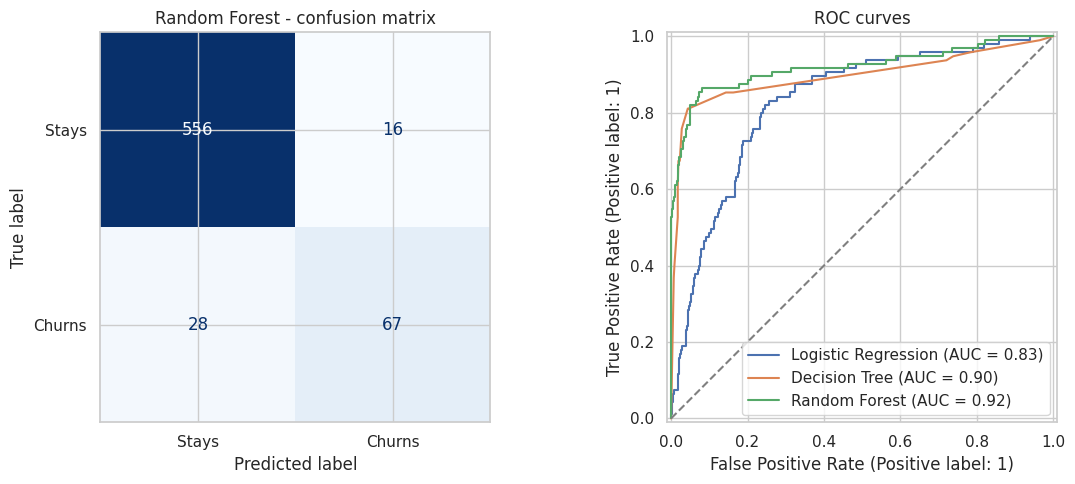

In [8]:
best_name = max(cv_scores, key=cv_scores.get)
best_model = tuned[best_name]
print("Final model:", best_name)

tn, fp, fn, tp = confusion_matrix(y_test, best_model.predict(X_test)).ravel()
print(f"{tp} churners found, {fn} missed, {fp} false alarms, {tn} correct 'stays'")
print()
print(classification_report(y_test, best_model.predict(X_test), target_names=["Stays", "Churns"], digits=3))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay.from_estimator(best_model, X_test, y_test, display_labels=["Stays", "Churns"],
                                      cmap="Blues", colorbar=False, ax=axes[0])
axes[0].set_title(f"{best_name} - confusion matrix")
for name, model in tuned.items():
    RocCurveDisplay.from_estimator(model, X_test, y_test, name=name, ax=axes[1])
axes[1].plot([0, 1], [0, 1], linestyle="--", color="gray")
axes[1].set_title("ROC curves")
plt.tight_layout()
plt.show()

On the test file the random forest finds 67 of the 95 churners, misses 28 and raises 16 false alarms. The ROC curves show it also has the best AUC (0.92) of the three.

### Which variables matter?

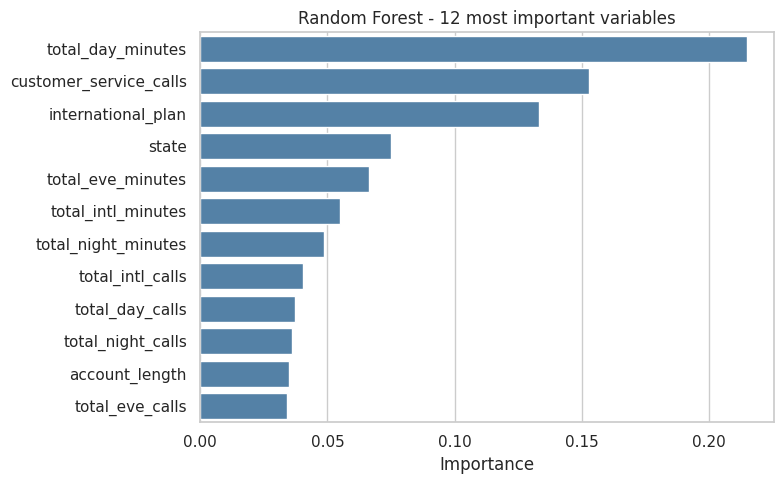

In [9]:
feature_names = best_model.named_steps["prep"].get_feature_names_out()
importances = pd.Series(best_model.named_steps["model"].feature_importances_, index=feature_names)
importances.index = [n.replace("num__", "").replace("cat__", "") for n in importances.index]

# one-hot encoding splits a variable in several columns, so I add them back together
def original_name(col):
    for cat in CATEGORICAL:
        if col.startswith(cat + "_"):
            return cat
    return col

top = importances.groupby(original_name).sum().sort_values(ascending=False).head(12)

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(x=top.values, y=top.index, color="steelblue", ax=ax)
ax.set_title(f"{best_name} - 12 most important variables")
ax.set_xlabel("Importance")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

The daytime minutes come first, then the number of customer service calls and the international plan. The calls and the plan match what the first charts showed. For the minutes, the 20% of customers who talk the most during the day (more than about 224 minutes) leave at a rate of 33%, against 7 to 14% for everybody else. In practice: heavy day-time users, customers who called support 4 times or more, and customers with an international plan are the ones to watch.

One limit: the model tells who is likely to leave, not why. A customer calling support many times may be leaving because of the problem that made him call.

---
## Task 3 - NLP: sentiment analysis

The data is 706 short social media posts (Twitter, Instagram, Facebook) after removing 26 duplicates. The goal is to classify each post as positive, negative or neutral.

In [10]:
df = pd.read_csv("data/sentiment_clean.csv", parse_dates=["timestamp"])
print(df.shape)
df[["text", "emotion", "platform", "country"]].head()

(706, 13)


,text,emotion,platform,country
0,Enjoying a beautiful day at the park!,Positive,Twitter,USA
1,Traffic was terrible this morning.,Negative,Twitter,Canada
2,Just finished an amazing workout! 💪,Positive,Instagram,USA
3,Excited about the upcoming weekend getaway!,Positive,Facebook,UK
4,Trying out a new recipe for dinner tonight.,Neutral,Instagram,Australia


### Preprocessing

Lower case, no links, mentions, digits or hashtag signs. Then tokenization, stopwords removal and lemmatization (`celebrating` becomes `celebrate`). The stopwords are removed only for the word analysis. For the sentiment scores I keep them, because a word like "not" changes the meaning.

In [11]:
def light_clean(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\.\S+", " ", text)
    text = re.sub(r"@\w+", " ", text)
    text = text.replace("#", " ")
    text = re.sub(r"[^a-z'\s]", " ", text)
    return re.sub(r"\s+", " ", text).strip()

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def to_tokens(clean_text):
    tokens = word_tokenize(clean_text)
    tokens = [t for t in tokens if t.isalpha() and len(t) > 2 and t not in stop_words]
    return [lemmatizer.lemmatize(lemmatizer.lemmatize(t, pos="v"), pos="n") for t in tokens]

df["clean_text"] = df["text"].apply(light_clean)
df["tokens"] = df["clean_text"].apply(to_tokens)

example = df.iloc[3]
print("original:", example["text"])
print("cleaned :", example["clean_text"])
print("tokens  :", example["tokens"])

original: Excited about the upcoming weekend getaway!
cleaned : excited about the upcoming weekend getaway
tokens  : ['excite', 'upcoming', 'weekend', 'getaway']


### Two sentiment tools

I score every post with **TextBlob** and with **VADER** (from nltk, made for short social media text). Both give a score from -1 to +1, and I use the usual band of 0.05 around zero for "neutral".

In [12]:
def to_label(score):
    if score >= 0.05:
        return "Positive"
    if score <= -0.05:
        return "Negative"
    return "Neutral"

ORDER = ["Positive", "Neutral", "Negative"]
COLORS = {"Positive": "seagreen", "Neutral": "gray", "Negative": "crimson"}

vader = SentimentIntensityAnalyzer()
df["textblob_score"] = df["clean_text"].apply(lambda t: TextBlob(t).sentiment.polarity)
df["vader_score"] = df["text"].apply(lambda t: vader.polarity_scores(t)["compound"])
df["textblob_sentiment"] = df["textblob_score"].apply(to_label)
df["vader_sentiment"] = df["vader_score"].apply(to_label)

print(pd.DataFrame({
    "TextBlob": df["textblob_sentiment"].value_counts().reindex(ORDER),
    "VADER": df["vader_sentiment"].value_counts().reindex(ORDER),
}))
print(f"\nthey agree on {(df['textblob_sentiment'] == df['vader_sentiment']).mean():.1%} of the posts")

          TextBlob  VADER
Positive       271    441
Neutral        312     82
Negative       123    183

they agree on 49.9% of the posts


They agree on only half of the posts, so they clearly do not read the texts the same way. Which one to trust?

### Checking the tools against the emotions of the file

The file has an `emotion` column but it holds 191 different emotions (Joy, Grief, Nostalgia...), not positive / negative / neutral. To have something to compare with, I grouped the emotions by hand into three classes. This is my own judgment and some emotions are debatable (nostalgia, surprise, curiosity...), so I put those in Neutral. The full mapping is saved in `results/emotion_mapping.csv`.

In [13]:
POSITIVE = """Positive Joy Excitement Contentment Gratitude Serenity Happy Hopeful Awe Pride Elation
Euphoria Enthusiasm Determination Playful Inspiration Happiness Hope Empowerment Inspired Admiration
Calmness Compassion Tenderness Fulfillment Reverence Proud Grateful Compassionate Thrill Enchantment
Love Amusement Kind Empathetic Free-spirited Confident Satisfaction Accomplishment Harmony Creativity
Wonder Adventure Enjoyment Affection Adoration Zest Radiance Rejuvenation Coziness Resilience
Tranquility Overjoyed Motivation JoyfulReunion Blessed Appreciation Confidence Wonderment Optimism
Mindfulness PlayfulJoy DreamChaser Elegance FestiveJoy Freedom Dazzle Adrenaline ArtisticBurst
CulinaryOdyssey Spark Marvel Positivity Kindness Friendship Success Amazement Romance Grandeur Energy
Celebration Charm Ecstasy Colorful Connection Iconic Engagement Touched Heartwarming Solace
Breakthrough Imagination Vibrancy Mesmerizing Triumph Captivation Melodic Hypnotic Whimsy Relief""".split()
POSITIVE += ["Joy in Baking", "Culinary Adventure", "Winter Magic", "Thrilling Journey", "Nature's Beauty",
             "Celestial Wonder", "Creative Inspiration", "Runway Creativity", "Ocean's Freedom"]

NEGATIVE = """Despair Grief Loneliness Sad Embarrassed Frustration Regret Numbness Melancholy Hate Bad
Disgust Bitterness Frustrated Betrayal Negative Boredom Overwhelmed Desolation Bitter Shame Jealousy
Resentment Fearful Jealous Devastated Envious Dismissive Heartbreak Anger Fear Sadness Disappointed
Anxiety Intimidation Helplessness Envy Apprehensive Isolation Disappointment Sorrow Loss Suffering
EmotionalStorm LostLove Exhaustion Darkness Desperation Ruins Heartache Obstacle Pressure
Miscalculation Confusion""".split()

emotion_group = {e: "Positive" for e in POSITIVE}
emotion_group.update({e: "Negative" for e in NEGATIVE})
df["emotion_group"] = df["emotion"].map(emotion_group).fillna("Neutral")
print(df["emotion_group"].value_counts().reindex(ORDER).to_dict())

clear = df["emotion_group"] != "Neutral"
for name in ("textblob", "vader"):
    col = f"{name}_sentiment"
    print(f"{name:>8}: accuracy {accuracy_score(df['emotion_group'], df[col]):.3f} on all posts | "
          f"{accuracy_score(df.loc[clear, 'emotion_group'], df.loc[clear, col]):.3f} on clearly positive/negative posts")

{'Positive': 412, 'Neutral': 105, 'Negative': 189}
textblob: accuracy 0.487 on all posts | 0.483 on clearly positive/negative posts
   vader: accuracy 0.766 on all posts | 0.854 on clearly positive/negative posts


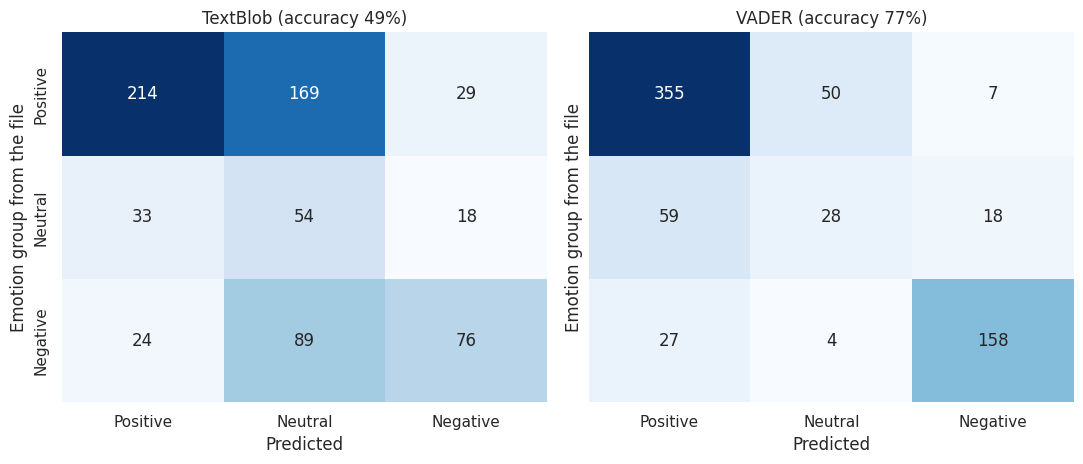

              precision    recall  f1-score   support

    Positive       0.80      0.86      0.83       412
     Neutral       0.34      0.27      0.30       105
    Negative       0.86      0.84      0.85       189

    accuracy                           0.77       706
   macro avg       0.67      0.65      0.66       706
weighted avg       0.75      0.77      0.76       706



In [14]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.8), sharey=True)
for ax, name, title in zip(axes, ["textblob", "vader"], ["TextBlob", "VADER"]):
    cm = pd.crosstab(df["emotion_group"], df[f"{name}_sentiment"]).reindex(index=ORDER, columns=ORDER, fill_value=0)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax)
    ax.set_title(f"{title} (accuracy {accuracy_score(df['emotion_group'], df[f'{name}_sentiment']):.0%})")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Emotion group from the file")
plt.tight_layout()
plt.show()

print(classification_report(df["emotion_group"], df["vader_sentiment"], labels=ORDER, digits=2, zero_division=0))

VADER is far better: 77% agreement with the grouped emotions against 49% for TextBlob, and 85% against 48% if I keep only the clearly positive or negative emotions (which does not depend on my choices for the ambiguous ones). Its weak point is the neutral class (F1 0.30), which is also where the grouping is the most debatable.

To see why TextBlob fails, here are positive posts that it calls negative and that VADER gets right:

In [15]:
wrong = df[(df["emotion_group"] == "Positive") & (df["textblob_sentiment"] == "Negative")
           & (df["vader_sentiment"] == "Positive")]
print(len(wrong), "posts like this. For example:\n")
for _, row in wrong.head(4).iterrows():
    print(f"  {row['text']}  (TextBlob {row['textblob_score']:.2f}, VADER {row['vader_score']:.2f})")

25 posts like this. For example:

  Feeling grateful for the little things in life.  (TextBlob -0.19, VADER 0.54)
  Late-night gaming session with friends.  (TextBlob -0.30, VADER 0.48)
  Reflecting on the importance of mental health.  (TextBlob -0.10, VADER 0.36)
  Gratitude for the support received during tough times.  (TextBlob -0.39, VADER 0.67)


TextBlob works word by word with a fixed dictionary, and some ordinary words such as "little", "late" or "mental" have a negative score in it, even in a sentence like "Feeling grateful for the little things in life". VADER's dictionary was built for social media text and it also looks at punctuation and capital letters.

From here I use **VADER** as the sentiment of each post.

### Sentiment distribution

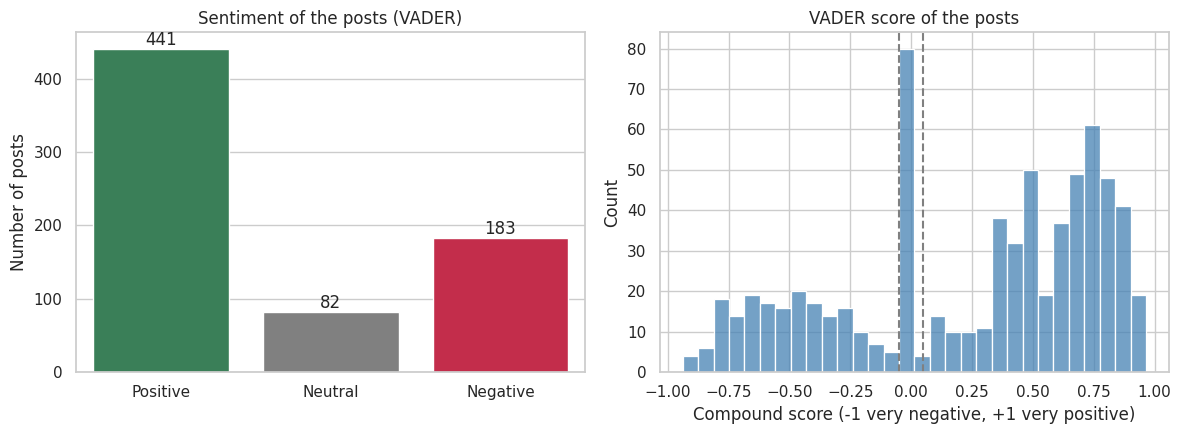

{'Positive': 62.5, 'Neutral': 11.6, 'Negative': 25.9}


In [16]:
df["sentiment"] = df["vader_sentiment"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.countplot(data=df, x="sentiment", order=ORDER, hue="sentiment", palette=COLORS, legend=False, ax=axes[0])
axes[0].set_title("Sentiment of the posts (VADER)")
axes[0].set_xlabel("")
axes[0].set_ylabel("Number of posts")
for container in axes[0].containers:
    axes[0].bar_label(container)
sns.histplot(df["vader_score"], bins=30, color="steelblue", ax=axes[1])
axes[1].axvline(0.05, color="gray", linestyle="--")
axes[1].axvline(-0.05, color="gray", linestyle="--")
axes[1].set_title("VADER score of the posts")
axes[1].set_xlabel("Compound score (-1 very negative, +1 very positive)")
plt.tight_layout()
plt.show()

counts = df["sentiment"].value_counts().reindex(ORDER)
print((counts / len(df) * 100).round(1).to_dict())

About 62% of the posts are positive, 26% negative and 12% neutral. The scores are pushed to the two ends: the neutral band in the middle is small, which is normal for short posts that express a clear feeling.

Sentiment by platform:

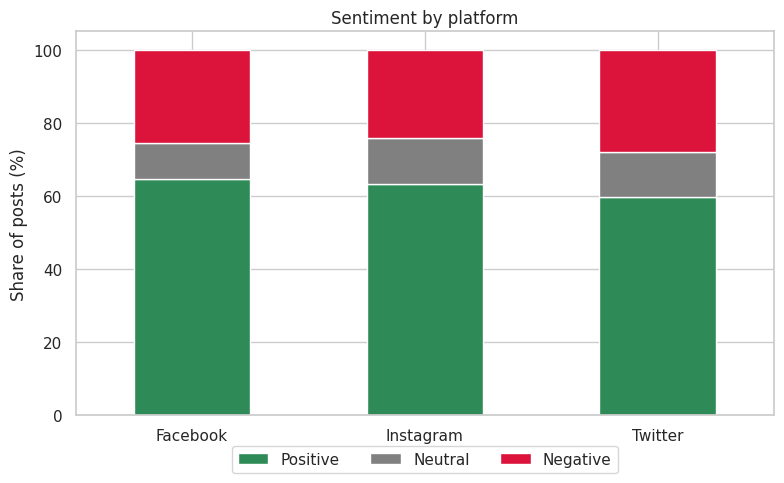

sentiment,Positive,Neutral,Negative
platform,,,
Facebook,64.6,9.9,25.6
Instagram,63.3,12.5,24.2
Twitter,59.6,12.3,28.1


In [17]:
by_platform = pd.crosstab(df["platform"], df["sentiment"], normalize="index")[ORDER] * 100
ax = by_platform.plot(kind="bar", stacked=True, color=[COLORS[c] for c in ORDER], figsize=(8, 5))
ax.set_title("Sentiment by platform")
ax.set_xlabel("")
ax.set_ylabel("Share of posts (%)")
plt.xticks(rotation=0)
ax.legend(title="", loc="upper center", bbox_to_anchor=(0.5, -0.06), ncol=3)
plt.tight_layout()
plt.show()
by_platform.round(1)

The three platforms look alike (60-65% positive). Twitter is slightly more negative (28%) but the differences are small for about 235 posts per platform, so I would not read much into them.

### Words: frequencies and word clouds

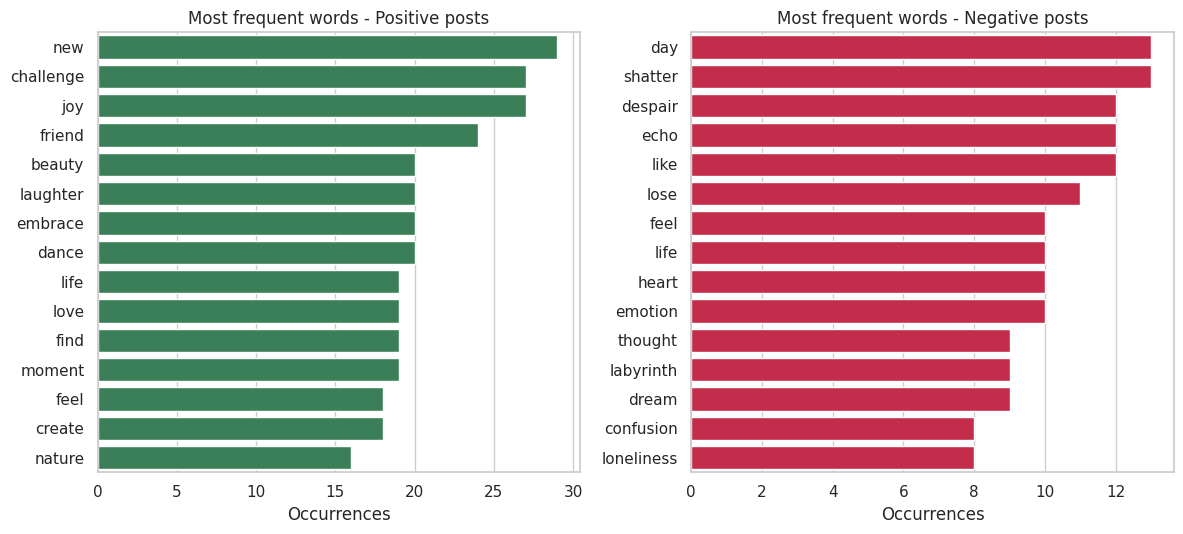

In [18]:
def top_words(sentiment, n=15):
    words = Counter(w for tokens in df.loc[df["sentiment"] == sentiment, "tokens"] for w in tokens)
    return words.most_common(n)

fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))
for ax, sentiment in zip(axes, ["Positive", "Negative"]):
    words, freq = zip(*top_words(sentiment))
    sns.barplot(x=list(freq), y=list(words), color=COLORS[sentiment], ax=ax)
    ax.set_title(f"Most frequent words - {sentiment} posts")
    ax.set_xlabel("Occurrences")
plt.tight_layout()
plt.show()

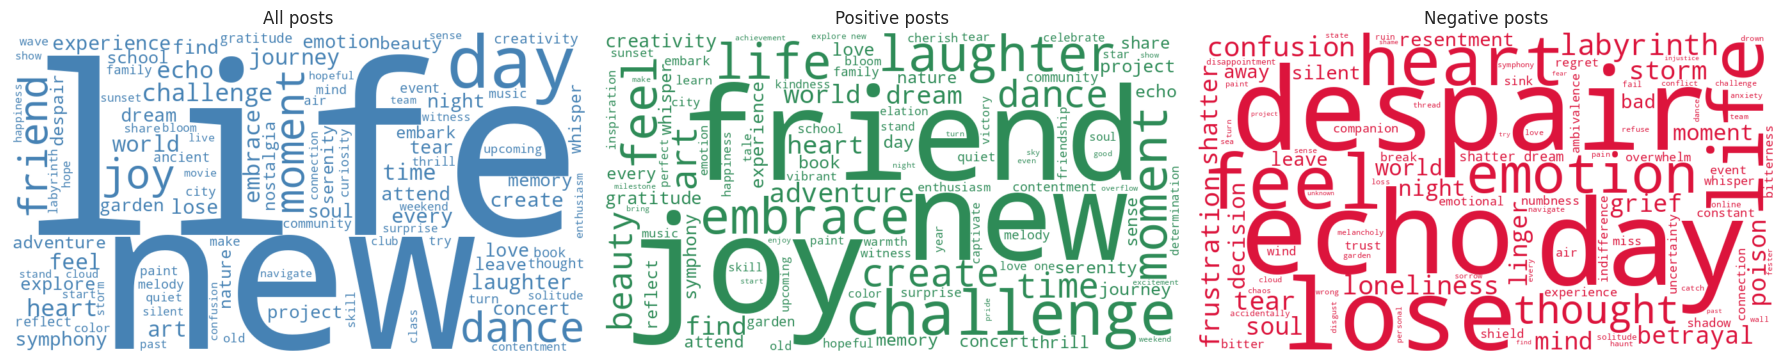

In [19]:
def word_cloud(tokens_series, color):
    text = " ".join(w for tokens in tokens_series for w in tokens)
    return WordCloud(width=900, height=500, background_color="white", max_words=100,
                     color_func=lambda *args, **kwargs: color, random_state=42).generate(text)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (title, series, color) in zip(axes, [
    ("All posts", df["tokens"], "steelblue"),
    ("Positive posts", df.loc[df["sentiment"] == "Positive", "tokens"], COLORS["Positive"]),
    ("Negative posts", df.loc[df["sentiment"] == "Negative", "tokens"], COLORS["Negative"]),
]):
    ax.imshow(word_cloud(series, color), interpolation="bilinear")
    ax.set_title(title)
    ax.axis("off")
plt.tight_layout()
plt.show()

Positive posts are full of words like *joy*, *friend*, *laughter*, *adventure*, *dance* and *beauty*. Negative ones are dominated by *despair*, *lose*, *shatter*, *loneliness*, *betrayal* and *frustration*. The word "life" is frequent in both, which is a good reminder that a word cloud shows what people talk about and not always how they feel about it.

### Limits

- The reference I used to check the tools comes from my own grouping of 191 emotions, so the accuracy figures are indicative. The gap between VADER and TextBlob is large enough to hold whatever the grouping of the debatable emotions.
- The posts are short, single-sentence texts, so the results may not carry over to long or messier real posts. Sarcasm, for example, would fool both tools.
- 706 posts is small, and the differences between platforms are within what chance can produce.

---
## Wrap-up

**Task 1.** On the churn data, tuned tree-based models find roughly 70-80% of the customers who leave, against 76% for a logistic regression that raises far more false alarms. The random forest, chosen by cross-validation, finds 67 of the 95 churners of the test file. Customers with 4 or more calls to customer service, with an international plan, or with high daytime usage are the main risk signals.

**Task 3.** VADER agrees with the emotions of the file on 77% of the posts, against 49% for TextBlob, so it is the tool I kept. About 62% of the posts are positive, 26% negative and 12% neutral, and the platforms behave similarly.

This is a school exercise on public datasets, not a production model.